<a href="https://colab.research.google.com/github/albertraviss2023/AI-PredictiveMaintenance/blob/master/Copy_of_part1_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1: Image classification
Classifing the images of the CIFAR-100 dataset using convolutional networks.

###### Listing 1.0: Loading Libraries

In [ ]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam, RMSprop
import numpy as np
import matplotlib.pyplot as plt
from keras.layers import Conv2D
import keras
from sklearn.model_selection import train_test_split

In [ ]:
# Download dataset of CIFAR-100
(x_train, y_train), (x_test, y_test) = cifar100.load_data()

# Check the shape of the array
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Number of samples in dataset
print(f"Train: {x_train.shape[0]}")
print(f"Test: {x_test.shape[0]}")

# Data format
print(type(x_train))
print(type(y_train))

x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)
Train: 50000
Test: 10000
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


### Preprocessing data

In [ ]:
# Import libraries for preprocessing images
from tensorflow.keras.utils import to_categorical

# Normalize images
train_images = x_train.astype('float32')/255
test_images = x_test.astype('float32')/255

# Transform labels to one hot encoding
train_labels = to_categorical(y_train)
test_labels = to_categorical(y_test)


## 1.1 Feature extraction and fine-tuning:

### 1. Use features extracted from the VGG16 classifier and a standalone classifier to classify the images (as explained in section 8.3.1).

#### Instantiating the VGG16 convolutional base

In [ ]:
conv_base = keras.applications.vgg16.VGG16(
weights="imagenet",
include_top=False,
input_shape=(32, 32, 3))

In [ ]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

The final feature map has shape (1, 1, 512). That’s the feature map on top of which
we’ll stick a densely connected classifier.

#### Extracting the VGG16 features and corresponding labels

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

def get_features_and_labels(images, labels, model):
    """
    Extract features and labels using a pre-trained convolutional base.

    Parameters:
    - images (numpy.ndarray): Input images.
    - labels (numpy.ndarray): Corresponding labels.
    - model: Pre-trained model for feature extraction.

    Returns:
    - tuple: Extracted features and labels as numpy arrays.
    """
    features = model.predict(images, verbose=1)
    return np.array(features), np.array(labels)

# Split the dataset (80% training, 20% validation)
train_images, val_images, train_labels, val_labels = train_test_split(
    train_images, train_labels, test_size=0.2, random_state=42
)

# Extract features for each dataset
train_features, train_labels = get_features_and_labels(train_images, train_labels, conv_base)
val_features, val_labels = get_features_and_labels(val_images, val_labels, conv_base)
test_features, test_labels = get_features_and_labels(test_images, test_labels, conv_base)

# Verify dataset shapes
print(f"Train features shape: {train_features.shape}, Train labels shape: {train_labels.shape}")
print(f"Validation features shape: {val_features.shape}, Validation labels shape: {val_labels.shape}")
print(f"Test features shape: {test_features.shape}, Test labels shape: {test_labels.shape}")

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Train features shape: (40000, 1, 1, 512), Train labels shape: (40000, 100)
Validation features shape: (10000, 1, 1, 512), Validation labels shape: (10000, 100)
Test features shape: (10000, 1, 1, 512), Test labels shape: (10000, 100)


The extracted features are currently of shape (samples, 1, 1, 512). We proceed to define a densely connected classifier regularization and train it on the features and labels that we just recorded.

#### Defining and training the densely connected classifier

##### Iteration 1: No regularization and two dense layers beofre output layer

In [ ]:
from tensorflow.keras import layers, models, callbacks, Input
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow import keras

# Define the input layer for pre-extracted VGG16 features
inputs = Input(shape=(1, 1, 512))

# Flatten the feature maps to a 1D vector
x = Flatten()(inputs)

# First Dense layer with Dropout
x = Dense(256, activation='relu')(x)
# Deeper fully connected layers with additional Dropout
x = Dense(1024, activation='relu')(x)
x = Dense(512, activation='relu')(x)
x = Dense(256, activation='relu')(x)

# Output layer with softmax for multi-class classification
outputs = Dense(100, activation='softmax')(x)

# Build the model
model = keras.Model(inputs, outputs)

# Compile the model
model.compile(
    loss="categorical_crossentropy",
    optimizer="rmsprop",
    metrics=["accuracy"]
)


# Callbacks: ModelCheckpoint + EarlyStopping
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="feature_extraction_l2.keras",
        save_best_only=True,
        monitor="val_loss"
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,              # Stop after 5 epochs with no improvement
        restore_best_weights=True
    )
]

# Train the model
history = model.fit(
    train_features, train_labels,
    epochs=100,
    validation_data=(val_features, val_labels),
    callbacks=callbacks
)


Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.1218 - loss: 3.7685 - val_accuracy: 0.2451 - val_loss: 3.0611
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.2718 - loss: 2.9187 - val_accuracy: 0.2861 - val_loss: 2.8748
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3188 - loss: 2.6911 - val_accuracy: 0.3072 - val_loss: 2.8176
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3550 - loss: 2.5135 - val_accuracy: 0.3067 - val_loss: 2.8671
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3812 - loss: 2.3879 - val_accuracy: 0.3068 - val_loss: 2.9189
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4056 - loss: 2.2701 - val_accuracy: 0.3194 - val_loss: 2.9192
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.4400 - loss: 2.1340 - val_accuracy: 0.3118 - val_loss: 3.0461
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4535 - loss: 2

#### plot the results

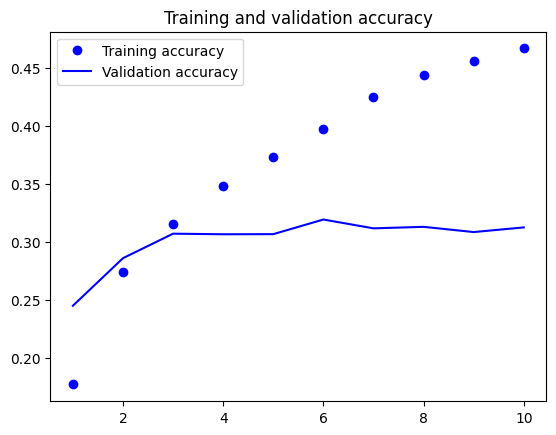

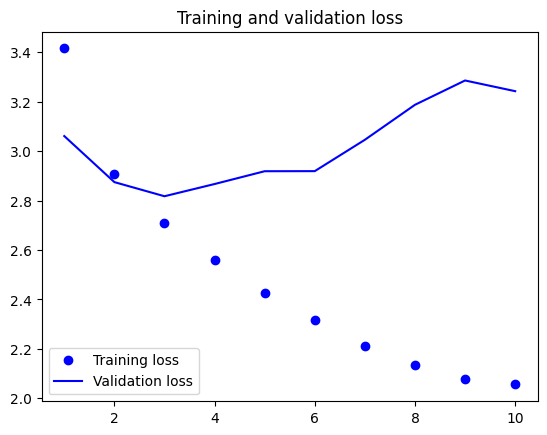

In [ ]:
import matplotlib.pyplot as plt
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "bo", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [ ]:
# Print the final test accuracy
test_loss, test_acc = model.evaluate(test_features, test_labels, verbose=0)
print(f"Test accuracy: {test_acc:.2f}")

Test accuracy: 0.31


The Model overfits very quickly and we may need to add some dropout regularization

##### Iteration 2: With dropout regularization and some additional dense  layers

In [ ]:
from tensorflow.keras import layers, models, callbacks, Input
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow import keras

# Define the input layer for pre-extracted VGG16 features
inputs = Input(shape=(1, 1, 512))

# Flatten the feature maps to a 1D vector
x = Flatten()(inputs)

# First Dense layer with Dropout
x = Dense(256, activation='relu')(x)
# Deeper fully connected layers with additional Dropout
x = Dense(1024, activation='relu')(x)
x = Dense(512, activation='relu')(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

# Output layer with softmax for multi-class classification
outputs = Dense(100, activation='softmax')(x)

# Build the model
model = keras.Model(inputs, outputs)

# Compile the model
model.compile(
    loss="categorical_crossentropy",
    optimizer="rmsprop",
    metrics=["accuracy"]
)


# Callbacks: ModelCheckpoint + EarlyStopping
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="feature_extraction_l2.keras",
        save_best_only=True,
        monitor="val_loss"
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,              # Stop after 5 epochs with no improvement
        restore_best_weights=True
    )
]

# Train the model
history = model.fit(
    train_features, train_labels,
    epochs=100,
    validation_data=(val_features, val_labels),
    callbacks=callbacks
)


Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.0906 - loss: 4.0127 - val_accuracy: 0.2296 - val_loss: 3.1458
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.2273 - loss: 3.1711 - val_accuracy: 0.2707 - val_loss: 2.9900
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.2721 - loss: 2.9804 - val_accuracy: 0.2835 - val_loss: 2.9240
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.2969 - loss: 2.8823 - val_accuracy: 0.2889 - val_loss: 2.9574
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3163 - loss: 2.7713 - val_accuracy: 0.2892 - val_loss: 3.0075
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3273 - loss: 2.7468 - val_accuracy: 0.3010 - val_loss: 2.9920
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.3286 - loss: 2.7585 - val_accuracy: 0.2921 - val_loss: 3.1140
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3236 - loss: 

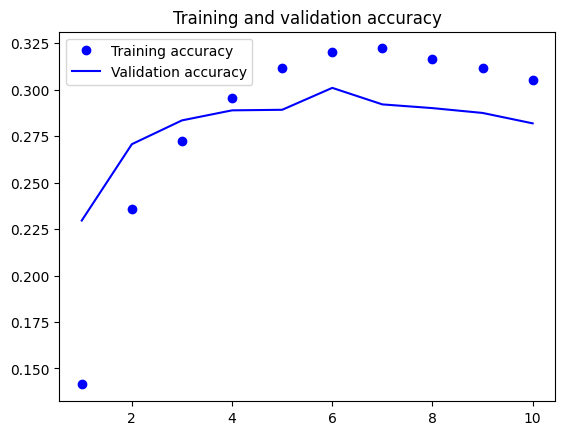

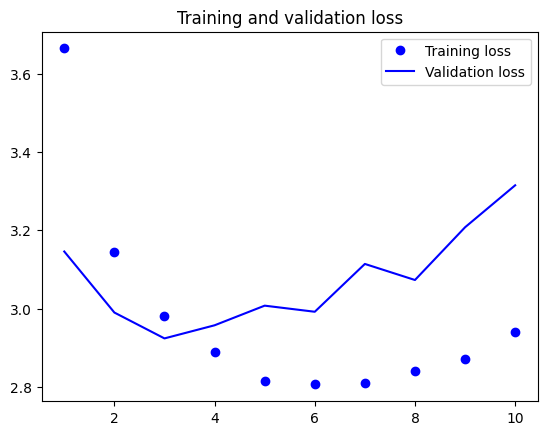

In [ ]:
import matplotlib.pyplot as plt
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "bo", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [ ]:
# Print the final test accuracy
test_loss, test_acc = model.evaluate(test_features, test_labels, verbose=0)
print(f"Test accuracy: {test_acc:.2f}")

Test accuracy: 0.28


##### Iteration 3: One Dense Layer before classifier and reduced dropout rate

In [ ]:
from tensorflow.keras import layers, models, callbacks, Input
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow import keras

# Define the input layer for pre-extracted VGG16 features
inputs = Input(shape=(1, 1, 512))

# Flatten the feature maps to a 1D vector
x = Flatten()(inputs)

# Deeper fully connected layers with additional Dropout
x = Dense(1024, activation='relu')(x)

x = Dropout(0.1)(x)

# Output layer with softmax for multi-class classification
outputs = Dense(100, activation='softmax')(x)

# Build the model
model = keras.Model(inputs, outputs)

# Compile the model
model.compile(
    loss="categorical_crossentropy",
    optimizer="rmsprop",
    metrics=["accuracy"]
)


# Callbacks: ModelCheckpoint + EarlyStopping
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="feature_extraction_l2.keras",
        save_best_only=True,
        monitor="val_loss"
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,              # Stop after 5 epochs with no improvement
        restore_best_weights=True
    )
]

# Train the model
history = model.fit(
    train_features, train_labels,
    epochs=100,
    validation_data=(val_features, val_labels),
    callbacks=callbacks
)


Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.1785 - loss: 3.5140 - val_accuracy: 0.3062 - val_loss: 2.8258
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.3179 - loss: 2.7065 - val_accuracy: 0.3313 - val_loss: 2.6943
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3618 - loss: 2.4902 - val_accuracy: 0.3452 - val_loss: 2.6488
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3909 - loss: 2.3623 - val_accuracy: 0.3490 - val_loss: 2.6371
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4091 - loss: 2.2770 - val_accuracy: 0.3548 - val_loss: 2.6497
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4274 - loss: 2.2094 - val_accuracy: 0.3550 - val_loss: 2.6679
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4499 - loss: 2.1136 - val_accuracy: 0.3541 - val_loss: 2.7682
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4635 - loss: 2

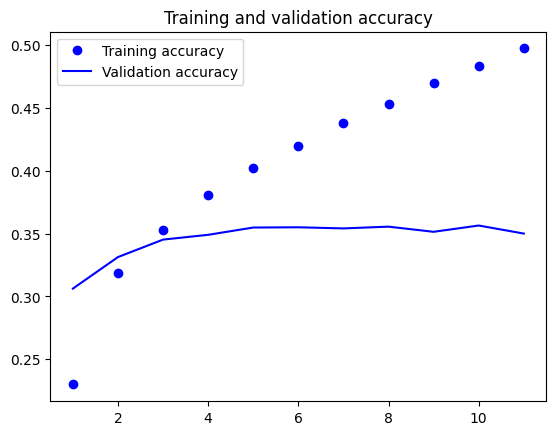

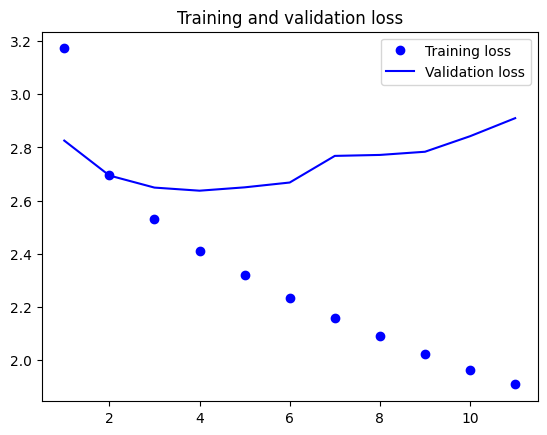

In [ ]:
import matplotlib.pyplot as plt
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "bo", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [ ]:
# Print the final test accuracy
test_loss, test_acc = model.evaluate(test_features, test_labels, verbose=0)
print(f"Test accuracy: {test_acc:.2f}")

Test accuracy: 0.34


There is an obvious Improvement from 28 to 34 percent.

### 2. Build an image classifier by extending the VGG convolutional base with a dense classification layer (as explained in section 8.3.1). Discuss the results.

In [ ]:
from tensorflow.keras.datasets import cifar100

# Load and split CIFAR-10 dataset into training and test sets
(x_train, y_train), (x_test, y_test) = cifar100.load_data()

# Normalize pixel values
x_train = x_train / 255.0
x_test = x_test / 255.0



In [ ]:

# Transform labels to one hot encoding
train_labels = to_categorical(y_train)
test_labels = to_categorical(y_test)

In [ ]:
train_images, val_images, train_labels, val_labels = train_test_split(
    x_train, train_labels, test_size=0.2, random_state=42
)


In [ ]:
conv_base = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False
)

# Enable training on the convolutional base initially
conv_base.trainable = True
print("Number of trainable weights before freezing the conv base:", len(conv_base.trainable_weights))

# Freeze the convolutional base
conv_base.trainable = False
print("Number of trainable weights after freezing the conv base:", len(conv_base.trainable_weights))


Number of trainable weights before freezing the conv base: 26
Number of trainable weights after freezing the conv base: 0


In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [ ]:
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Flatten, Dense, Resizing

# Define the model using data augmentation and the VGG16 base model
inputs = Input(shape=(32, 32, 3))  # Define input shape for CIFAR-10 dataset

# Apply data augmentation
x = data_augmentation(inputs)  # Apply random flips, rotations, and zooms
x = conv_base(x)  # Feature extraction using VGG16

# Flatten the feature maps into a single vector
x = Flatten()(x)

# Add fully connected layers for classification
x = Dense(1024, activation='relu')(x)
x = Dense(512, activation='relu')(x)
x = Dense(256, activation='relu')(x)
x = Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
# Final output layer for CIFAR-100 classification (10 classes)
outputs = Dense(100, activation='softmax')(x)

# Create the model
model = Model(inputs, outputs)

In [ ]:
# Compile the model
model.compile(
    loss="categorical_crossentropy",
    optimizer="rmsprop",
    metrics=["accuracy"]
)

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=7,               # Stop training if val_loss doesn't improve for 7 epochs
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath='best_model.keras',  # Save the best model to this file
        monitor='val_loss',
        save_best_only=True
    )
]

# Train the model
history = model.fit(
    train_images,               # Corrected to use split training data
    train_labels,
    validation_data=(val_images, val_labels),
    batch_size=64,
    epochs=100,
    callbacks=callbacks,         # Callbacks added here
    verbose=1
)


Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.0707 - loss: 4.1516 - val_accuracy: 0.2097 - val_loss: 3.2556
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.1949 - loss: 3.3418 - val_accuracy: 0.2386 - val_loss: 3.0847
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.2318 - loss: 3.1368 - val_accuracy: 0.2764 - val_loss: 2.9140
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.2638 - loss: 3.0099 - val_accuracy: 0.2740 - val_loss: 2.9285
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.2785 - loss: 2.9157 - val_accuracy: 0.2914 - val_loss: 2.9040
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.2922 - loss: 2.8463 - val_accuracy: 0.2873 - val_loss: 2.8995
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.3064 - loss: 2.7995 - val_accuracy: 0.3011 - val_loss: 2.8363
Epoch 8/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.3189 - loss: 2

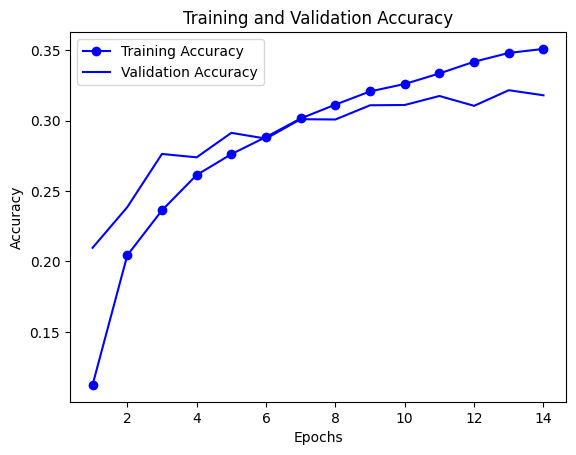

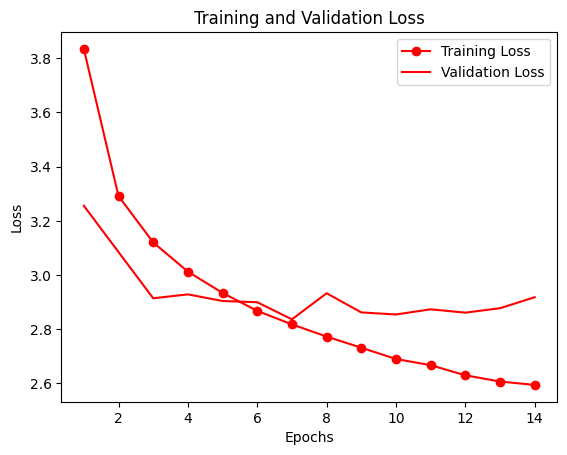

In [ ]:
import matplotlib.pyplot as plt

# Extract training and validation accuracy/loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# Plot training and validation accuracy
plt.plot(epochs, acc, 'bo-', label='Training Accuracy')  # Blue dots and line
plt.plot(epochs, val_acc, 'b-', label='Validation Accuracy')  # Blue solid line
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.figure()
plt.plot(epochs, loss, 'ro-', label='Training Loss')  # Red dots and line
plt.plot(epochs, val_loss, 'r-', label='Validation Loss')  # Red solid line
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# Evaluate the model on the test dataset
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)

# Print the test accuracy
print(f"Test accuracy: {test_acc:.2f}")

Test accuracy: 0.30


### 3. Using the classifier built in the previous step as a starting point, fine-tune the last block of the convolutional base of the VGG16 network (as explained in section 8.3.2). Discuss the results.

We already completed the first three steps when
doing feature extraction. Let’s proceed with step 4:
we’ll unfreeze our conv_base and then freeze individual layers inside it.

In [ ]:
conv_base  = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False)
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, None, None,     │     1,180,160 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │             

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

We’ll fine-tune the last three convolutional layers, which means all layers up to block4_
pool should be frozen, and the layers block5_conv1, block5_conv2, and block5_conv3
should be trainable.

In [ ]:
conv_base.trainable = True
for layer in conv_base.layers[:-4]:
    layer.trainable = False

As expected we have zero non trainable weights

#### Fine-tuning the model

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=7,               # Stop training if val_loss doesn't improve for 7 epochs
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath='best_model_finetuned.keras',  # Save the best model to this file
        monitor='val_loss',
        save_best_only=True
    )
]

# Train the model
history = model.fit(
    train_images,               # Corrected to use split training data
    train_labels,
    validation_data=(val_images, val_labels),
    batch_size=64,
    epochs=100,
    callbacks=callbacks,         # Callbacks added here
    verbose=1
)


Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.3662 - loss: 2.4631 - val_accuracy: 0.3298 - val_loss: 2.7515
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.3690 - loss: 2.4669 - val_accuracy: 0.3310 - val_loss: 2.7493
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.3649 - loss: 2.4780 - val_accuracy: 0.3321 - val_loss: 2.7471
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.3724 - loss: 2.4452 - val_accuracy: 0.3318 - val_loss: 2.7427
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.3706 - loss: 2.4544 - val_accuracy: 0.3327 - val_loss: 2.7461
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.3705 - loss: 2.4586 - val_accuracy: 0.3326 - val_loss: 2.7462
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.3727 - loss: 2.4414 - val_accuracy: 0.3324 - val_loss: 2.7449
Epoch 8/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.3735 - loss: 2

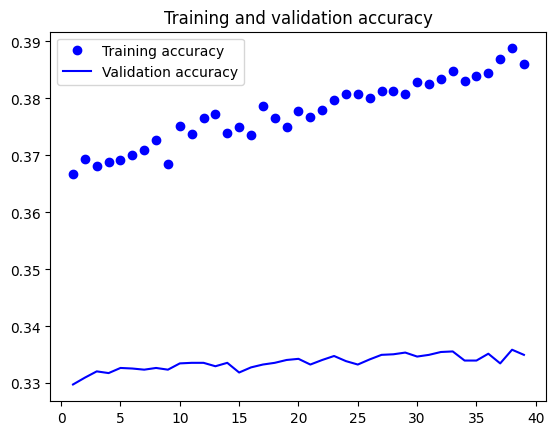

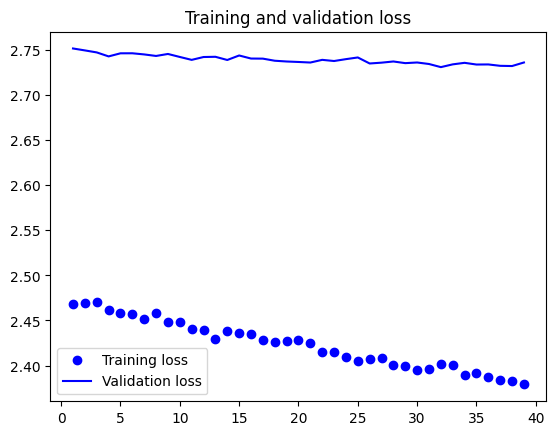

In [ ]:
import matplotlib.pyplot as plt
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "bo", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [ ]:
# Print the final test accuracy
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)
print(f"Test accuracy: {test_acc:.2f}")

Test accuracy: 0.34


Test accuracy rises to 34% with the finetuned model

## 1.2. Creating the CNN network from scratch:

### Iteration 1: Base CNN model

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

# Define the input layer
inputs = keras.Input(shape=(32, 32, 3))  # Input shape is 32x32x3, similar to the Sequential model
x = layers.Rescaling(1./255)(inputs)
# Build the convolutional layers with pooling
x = layers.Conv2D(32, (3, 3), activation="relu")(inputs)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Conv2D(64, (3, 3), activation="relu")(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Conv2D(64, (3, 3), activation="relu")(x)
x = layers.MaxPooling2D((2, 2))(x)

# Add the classifier layers
x = layers.Flatten()(x)
x = layers.Dense(64, activation="relu")(x)  # Dense layer with 64 units and ReLU activation
outputs = layers.Dense(100, activation="softmax")(x)  # Output layer with 100 units for CIFAR-100 classes

# Define the model
model = keras.Model(inputs=inputs, outputs=outputs)

# Print the summary
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 4, 4, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 2, 2, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 100)                 │           6,500 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 79,268 (309.64 KB)

 Trainable params: 79,268 (309.64 KB)

 Non-trainable params: 0 (0.00 B)

### Configure model for training

In [ ]:
# Configure the model for training
from tensorflow.keras import optimizers
model.compile(loss='categorical_crossentropy',
              optimizer=optimizers.RMSprop(learning_rate=1e-4),
              metrics=['accuracy'])

### Train Model

In [ ]:
# Train the model
history = model.fit(
    train_images, train_labels,
    steps_per_epoch=100,
    epochs=400,
    batch_size=32,
    validation_data=(val_images, val_labels)
    ,verbose=1)

Epoch 1/400
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.0131 - loss: 4.6047 - val_accuracy: 0.0078 - val_loss: 4.6014
Epoch 2/400
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0115 - loss: 4.5975 - val_accuracy: 0.0103 - val_loss: 4.5922
Epoch 3/400
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0156 - loss: 4.5874 - val_accuracy: 0.0181 - val_loss: 4.5812
Epoch 4/400
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0195 - loss: 4.5751 - val_accuracy: 0.0194 - val_loss: 4.5606
Epoch 5/400
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0168 - loss: 4.5540 - val_accuracy: 0.0252 - val_loss: 4.5398
Epoch 6/400
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0198 - loss: 4.5341 - val_accuracy: 0.0247 - val_loss: 4.5040
Epoch 7/400
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0237 - loss: 4.5034 - val_accuracy: 0.0270 - val_loss: 4.4726
Epoch 8/400
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0276 - loss: 4.4863 - val_acc

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0374 - loss: 4.3381 - val_accuracy: 0.0433 - val_loss: 4.3451
Epoch 14/400
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0439 - loss: 4.3340 - val_accuracy: 0.0390 - val_loss: 4.3193
Epoch 15/400
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0400 - loss: 4.3399 - val_accuracy: 0.0399 - val_loss: 4.2978
Epoch 16/400
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0434 - loss: 4.3255 - val_accuracy: 0.0431 - val_loss: 4.2788
Epoch 17/400
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0507 - loss: 4.2906 - val_accuracy: 0.0447 - val_loss: 4.2668
Epoch 18/400
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0414 - loss: 4.2827 - val_accuracy: 0.0532 - val_loss: 4.2572
Epoch 19/400
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0494 - loss: 4.2558 - val_accuracy: 0.0533 - val_loss: 4.2368
Epoch 20/400
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0581 - loss: 4.2333 - val_accuracy:

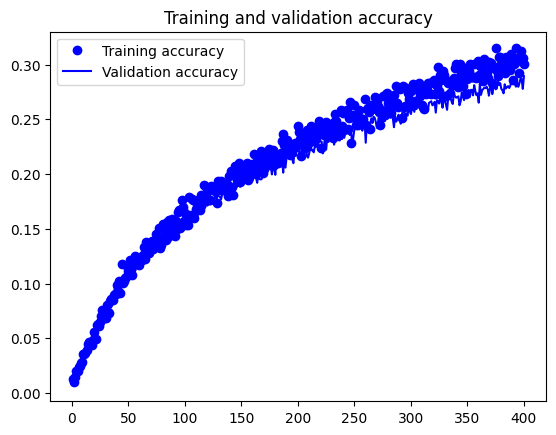

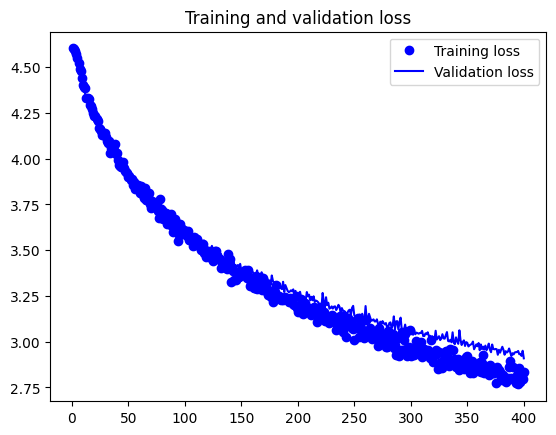

In [ ]:
import matplotlib.pyplot as plt
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [ ]:
# Print the final test accuracy
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)
print(f"Test accuracy: {test_acc:.2f}")

Test accuracy: 0.29


### Iteration 2: # increasing layers and nodes + Dropout with data augmentation

In [ ]:
data_augmentation = keras.Sequential(
    [
 layers.RandomFlip("horizontal"),
 layers.RandomRotation(0.1),
 layers.RandomZoom(0.2),
    ]
 )

In [ ]:
from tensorflow.keras import layers, models, optimizers

# Input layer
inputs = layers.Input(shape=(32, 32, 3))
x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)
# Stack 1
x = layers.Conv2D(64, (3, 3), activation='relu')(inputs)
x = layers.Conv2D(64, (3, 3), activation='relu')(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.2)(x)

# Stack 2
x = layers.Conv2D(128, (3, 3), activation='relu')(x)
x = layers.Conv2D(128, (3, 3), activation='relu')(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.2)(x)

# Classifier
x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(100, activation='softmax')(x)  # CIFAR-100 has 100 classes

# Define the model
model = models.Model(inputs=inputs, outputs=outputs)

# Print summary
model.summary()

# Configure the model for training
from tensorflow.keras import optimizers
model.compile(loss='categorical_crossentropy',
              optimizer=optimizers.RMSprop(learning_rate=1e-4),
              metrics=['accuracy'])

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 30, 30, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 28, 28, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 10, 10, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 5, 5, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 5, 5, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 3200)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │         409,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 256)                 │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 512)                 │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 100)                 │          51,300 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 885,796 (3.38 MB)

 Trainable params: 885,796 (3.38 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

# Train the model
history = model.fit(
    train_images, train_labels,
    steps_per_epoch=100,
    epochs=400,
    batch_size=32,
    validation_data=(val_images, val_labels)
    ,verbose=1)

Epoch 1/400
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.0102 - loss: 4.6063 - val_accuracy: 0.0120 - val_loss: 4.6034
Epoch 2/400
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.0106 - loss: 4.6029 - val_accuracy: 0.0135 - val_loss: 4.5950
Epoch 3/400
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.0118 - loss: 4.5867 - val_accuracy: 0.0224 - val_loss: 4.5152
Epoch 4/400
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.0186 - loss: 4.5119 - val_accuracy: 0.0247 - val_loss: 4.4405
Epoch 5/400
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.0248 - loss: 4.4294 - val_accuracy: 0.0344 - val_loss: 4.3834
Epoch 6/400
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.0315 - loss: 4.3880 - val_accuracy: 0.0359 - val_loss: 4.3108
Epoch 7/400
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.0334 - loss: 4.3680 - val_accuracy: 0.0393 - val_loss: 4.2759
Epoch 8/400
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.0407 - loss: 4.3075 - 

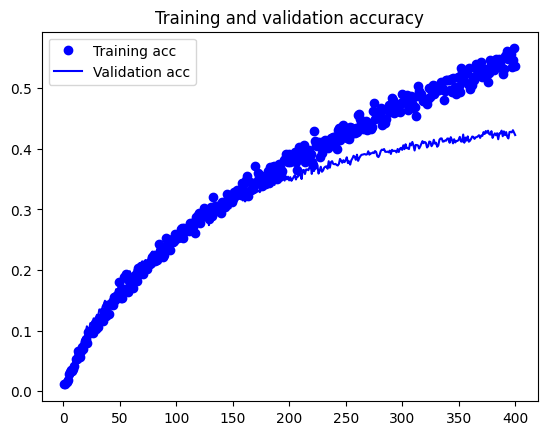

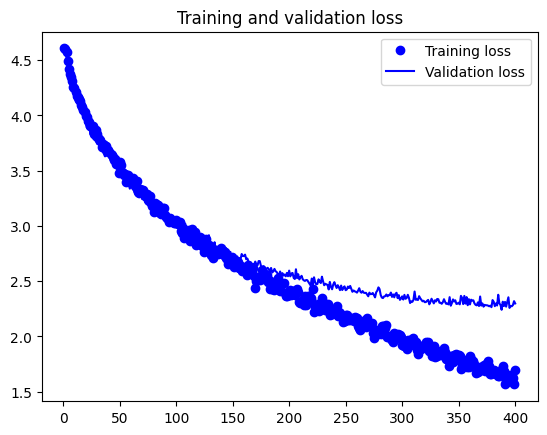

In [ ]:
# Plot function for visualisation training process
import matplotlib.pyplot as plt

def training_plot(history):
  acc = history.history['accuracy']
  val_acc = history.history['val_accuracy']
  loss = history.history['loss']
  val_loss = history.history['val_loss']
  epochs = range(1, len(acc) + 1)
  plt.plot(epochs, acc, 'bo', label='Training acc')
  plt.plot(epochs, val_acc, 'b', label='Validation acc')
  plt.title('Training and validation accuracy')
  plt.legend()
  plt.figure()
  plt.plot(epochs, loss, 'bo', label='Training loss')
  plt.plot(epochs, val_loss, 'b', label='Validation loss')
  plt.title('Training and validation loss')
  plt.legend()
  plt.show()

training_plot(history)

In [ ]:
# Print the final test accuracy
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)
print(f"Test accuracy: {test_acc:.2f}")

Test accuracy: 0.43


### Iteration 3: Data Augmentation, Batch normalization and Dropout regularization

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.initializers import RandomNormal, Constant

# Input layer
inputs = layers.Input(shape=(32, 32, 3))
x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)
# Stack 1
x = layers.Conv2D(256, (3, 3), padding='same')(inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Conv2D(256, (3, 3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.2)(x)

# Stack 2
x = layers.Conv2D(512, (3, 3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Conv2D(512, (3, 3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.2)(x)

# Stack 3
x = layers.Conv2D(512, (3, 3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Conv2D(512, (3, 3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.2)(x)

# Stack 4
x = layers.Conv2D(512, (3, 3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Conv2D(512, (3, 3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.2)(x)

# Classifier
x = layers.Flatten()(x)
# added more layers to the classifier; 256 and 512
x = layers.Dense(256)(x)
x = layers.Dense(512)(x)
x = layers.Dense(1024)(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.2)(x)
x = layers.BatchNormalization(
    momentum=0.95,
    epsilon=0.005,
    beta_initializer=RandomNormal(mean=0.0, stddev=0.05),
    gamma_initializer=Constant(value=0.9)
)(x)
outputs = layers.Dense(100, activation='softmax')(x)

# Define the model
model = models.Model(inputs=inputs, outputs=outputs)

# Print the model summary
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)           │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 32, 32, 256)         │           7,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 32, 32, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 32, 32, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 32, 32, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32, 32, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 32, 32, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 16, 16, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 16, 16, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 16, 16, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 16, 16, 512)         │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 16, 16, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 16, 16, 512)         │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 16, 16, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 8, 8, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 8, 8, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 8, 8, 512)           │           2,048 │
│ (BatchNormalization)                 │                             │              

 Total params: 14,878,820 (56.76 MB)

 Trainable params: 14,869,604 (56.72 MB)

 Non-trainable params: 9,216 (36.00 KB)

In [ ]:
# Configure the model for training
from tensorflow.keras import optimizers
model.compile(loss='categorical_crossentropy',
              optimizer=optimizers.RMSprop(learning_rate=1e-4),
              metrics=['accuracy'])

In [ ]:
# Train the model
history = model.fit(
    train_images, train_labels,
    steps_per_epoch=100,
    epochs=400,
    batch_size=32,
    validation_data=(val_images, val_labels)
    ,verbose=1)

Epoch 1/400
100/100 ━━━━━━━━━━━━━━━━━━━━ 38s 191ms/step - accuracy: 0.0200 - loss: 4.9036 - val_accuracy: 0.0114 - val_loss: 4.8143
Epoch 2/400
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 160ms/step - accuracy: 0.0402 - loss: 4.5450 - val_accuracy: 0.0122 - val_loss: 4.9806
Epoch 3/400
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 154ms/step - accuracy: 0.0566 - loss: 4.3346 - val_accuracy: 0.0147 - val_loss: 5.1642
Epoch 4/400
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 150ms/step - accuracy: 0.0612 - loss: 4.2261 - val_accuracy: 0.0283 - val_loss: 4.9612
Epoch 5/400
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 149ms/step - accuracy: 0.0761 - loss: 4.1173 - val_accuracy: 0.0365 - val_loss: 4.7745
Epoch 6/400
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 151ms/step - accuracy: 0.0976 - loss: 4.0681 - val_accuracy: 0.0700 - val_loss: 4.2315
Epoch 7/400
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 153ms/step - accuracy: 0.0934 - loss: 3.9849 - val_accuracy: 0.1011 - val_loss: 3.9020
Epoch 8/400
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 154ms/step - accuracy: 0.1172 -

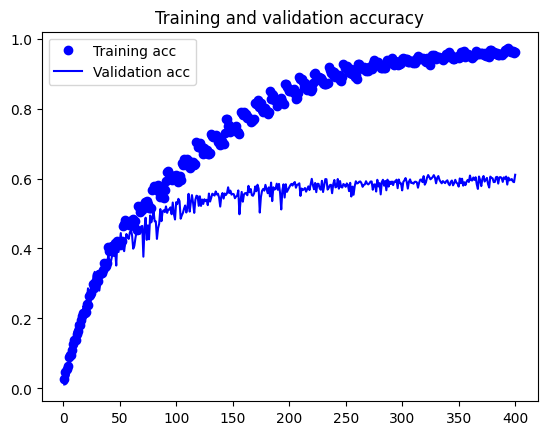

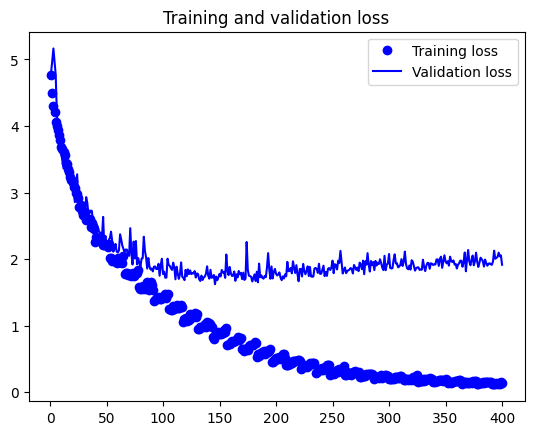

In [ ]:
# Visualize training process
training_plot(history)

In [ ]:
# Print the final test accuracy
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)
print(f"Test accuracy: {test_acc:.2f}")

Test accuracy: 0.60


In [ ]:
# save model
# Save the entire model to a .keras file
model.save('/kaggle/working/model_batchnorm_dataaug_dropout.keras')


In [ ]:
import json

# Save training history
with open('/kaggle/working/history_batchnorm_dataaug_dropout.json', 'w') as f:
    json.dump(history.history, f)


#### Keras call backs

Keras Callbacks Used

- **EarlyStopping** – Stops training when the model stops improving to prevent overfitting.
- **ModelCheckpoint** – Saves the best model during training based on validation loss.
- **ReduceLROnPlateau** – Reduces the learning rate when a monitored metric has stopped improving.


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Define callbacks
early_stop = EarlyStopping(
    monitor='val_loss',       # Metric to monitor
    patience=10,              # Number of epochs to wait before stopping
    restore_best_weights=True # Restore weights from the best epoch
)

checkpoint = ModelCheckpoint(
    filepath='best_model.keras', # File to save the best model
    monitor='val_loss',       # Metric to monitor
    save_best_only=True,      # Only save if the model improves
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',       # Metric to monitor
    factor=0.5,               # Reduce learning rate by this factor
    patience=5,               # Number of epochs to wait before reducing
    verbose=1,
    min_lr=1e-6               # Lower bound on the learning rate
)

# Train the model with callbacks
history = model.fit(
    train_images, train_labels,
    steps_per_epoch=100,
    epochs=400,
    batch_size=32,
    validation_data=(val_images, val_labels),
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)


Epoch 1/400
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9706 - loss: 0.1078
Epoch 1: val_loss improved from inf to 1.91370, saving model to best_model.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 163ms/step - accuracy: 0.9706 - loss: 0.1078 - val_accuracy: 0.6030 - val_loss: 1.9137 - learning_rate: 1.0000e-04
Epoch 2/400
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9664 - loss: 0.1158
Epoch 2: val_loss did not improve from 1.91370
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 163ms/step - accuracy: 0.9664 - loss: 0.1159 - val_accuracy: 0.5909 - val_loss: 1.9614 - learning_rate: 1.0000e-04
Epoch 3/400
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9614 - loss: 0.1446
Epoch 3: val_loss improved from 1.91370 to 1.89256, saving model to best_model.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 167ms/step - accuracy: 0.9615 - loss: 0.1445 - val_accuracy: 0.6075 - val_loss: 1.8926 - learning_rate: 1.0000e-04
Epoch 4/400
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9609 - loss

In [ ]:
# save model
# Save the entire model to a .keras file
model.save('/kaggle/working/model_batchnorm_dataaug_dropout_with_call_backs.keras')

In [ ]:
# Print the final test accuracy
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)
print(f"Test accuracy: {test_acc:.2f}")

Test accuracy: 0.66


With early stoping we managed to save time by stopping when there was no improvements and the learning rate scheduling optimized the training yielding a 6% improvement in generalization on test data.

#### Iteration 4: With residual Connections

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.initializers import RandomNormal, Constant

# Residual block definition
def residual_block(x, filters, pooling=False):
    residual = x

    # Convolutional path
    x = layers.Conv2D(filters, 3, activation="relu", padding="same")(x)
    x = layers.Conv2D(filters, 3, activation="relu", padding="same")(x)

    # If pooling is needed
    if pooling:
        x = layers.MaxPooling2D(2, padding="same")(x)
        residual = layers.Conv2D(filters, 1, strides=2)(residual)  # Adjust residual to match output dimensions
    elif filters != residual.shape[-1]:
        residual = layers.Conv2D(filters, 1)(residual)  # Match filters if they differ

    # Add the residual connection
    x = layers.add([x, residual])
    return x

# Input layer
inputs = layers.Input(shape=(32, 32, 3))
x = layers.Rescaling(1./255)(inputs)

# Residual Blocks
x = residual_block(x, filters=32, pooling=True)  # First residual block with pooling
x = residual_block(x, filters=64, pooling=True)  # Second residual block with pooling
x = residual_block(x, filters=128, pooling=True)
x = residual_block(x, filters=512, pooling=False) # Third residual block without pooling
# Final layers
x = layers.GlobalAveragePooling2D()(x)  # Global average pooling instead of flattening
x = layers.Dense(256)(x)
x = layers.Dense(512)(x)
x = layers.Dense(1024)(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.2)(x)
x = layers.BatchNormalization(
    momentum=0.95,
    epsilon=0.005,
    beta_initializer=RandomNormal(mean=0.0, stddev=0.05),
    gamma_initializer=Constant(value=0.9)
)(x)
outputs = layers.Dense(100, activation='softmax')(x)

# Define the model
model = models.Model(inputs=inputs, outputs=outputs)
model.summary()


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8             │ (None, 32, 32, 3)      │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_6 (Rescaling)   │ (None, 32, 32, 3)      │              0 │ input_layer_8[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_39 (Conv2D)        │ (None, 32, 32, 32)     │            896 │ rescaling_6[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_40 (Conv2D)        │ (None, 32, 32, 32)     │          9,248 │ conv2d_39[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_17          │ (None, 16, 16, 32)     │              0 │ conv2d_40[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_41 (Conv2D)        │ (None, 16, 16, 32)     │            128 │ rescaling_6[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_7 (Add)               │ (None, 16, 16, 32)     │              0 │ max_pooling2d_17[0][0… │
│                           │                        │                │ conv2d_41[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_42 (Conv2D)        │ (None, 16, 16, 64)     │         18,496 │ add_7[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_43 (Conv2D)        │ (None, 16, 16, 64)     │         36,928 │ conv2d_42[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_18          │ (None, 8, 8, 64)       │              0 │ conv2d_43[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_44 (Conv2D)        │ (None, 8, 8, 64)       │          2,112 │ add_7[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_8 (Add)               │ (None, 8, 8, 64)       │              0 │ max_pooling2d_18[0][0… │
│                           │                        │                │ conv2d_44[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_45 (Conv2D)        │ (None, 8, 8, 128)      │         73,856 │ add_8[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_46 (Conv2D)        │ (None, 8, 8, 128)      │        147,584 │ conv2d_45[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_19          │ (None, 4, 4, 128)      │              0 │ conv2d_46[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_47 (Conv2D)        │ (None, 4, 4, 128)      │          8,320 │ add_8[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_9 (Add)          

 Total params: 4,208,580 (16.05 MB)

 Trainable params: 4,206,532 (16.05 MB)

 Non-trainable params: 2,048 (8.00 KB)

In [ ]:
# Configure the model for training
from tensorflow.keras import optimizers
model.compile(loss='categorical_crossentropy',
              optimizer=optimizers.RMSprop(learning_rate=1e-4),
              metrics=['accuracy'])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Define callbacks
early_stop = EarlyStopping(
    monitor='val_loss',       # Metric to monitor
    patience=10,              # Number of epochs to wait before stopping
    restore_best_weights=True # Restore weights from the best epoch
)

checkpoint = ModelCheckpoint(
    filepath='best_model.keras', # File to save the best model
    monitor='val_loss',       # Metric to monitor
    save_best_only=True,      # Only save if the model improves
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',       # Metric to monitor
    factor=0.5,               # Reduce learning rate by this factor
    patience=5,               # Number of epochs to wait before reducing
    verbose=1,
    min_lr=1e-6               # Lower bound on the learning rate
)

# Train the model with callbacks
history = model.fit(
    train_images, train_labels,
    steps_per_epoch=100,
    epochs=400,
    batch_size=32,
    validation_data=(val_images, val_labels),
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)


Epoch 1/400
 97/100 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0075 - loss: 4.6108
Epoch 1: val_loss improved from inf to 4.60787, saving model to best_model.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 55ms/step - accuracy: 0.0075 - loss: 4.6107 - val_accuracy: 0.0106 - val_loss: 4.6079 - learning_rate: 1.0000e-04
Epoch 2/400
 97/100 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0121 - loss: 4.6070
Epoch 2: val_loss improved from 4.60787 to 4.60730, saving model to best_model.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.0121 - loss: 4.6070 - val_accuracy: 0.0123 - val_loss: 4.6073 - learning_rate: 1.0000e-04
Epoch 3/400
 97/100 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0111 - loss: 4.6087
Epoch 3: val_loss improved from 4.60730 to 4.60420, saving model to best_model.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.0111 - loss: 4.6087 - val_accuracy: 0.0103 - val_loss: 4.6042 - learning_rate: 1.0000e-04
Epoch 4/400
 97/100 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/

In [ ]:
# Print the final test accuracy
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)
print(f"Test accuracy: {test_acc:.2f}")

Test accuracy: 0.19


In [ ]:
# save model
# Save the entire model to a .keras file
model.save('/kaggle/working/model_batchnorm_dataaug_dropout_with_call_backs_res_connections.keras')

#### Iteration 5 Deptwise separable Convolutions

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.initializers import RandomNormal, Constant

# Input & preprocessing
inputs = keras.Input(shape=(32, 32, 3))
x = data_augmentation(inputs)
x = layers.Rescaling(1. / 255)(x)

# Initial Conv Layer
x = layers.Conv2D(filters=32, kernel_size=5, use_bias=False)(x)

# Residual convolutional blocks using a loop
for size in [32, 64, 128, 256, 512]:
    residual = x
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.SeparableConv2D(size, 3, padding="same", use_bias=False)(x)

    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.SeparableConv2D(size, 3, padding="same", use_bias=False)(x)

    x = layers.MaxPooling2D(3, strides=2, padding="same")(x)

    # Residual path (1x1 conv to match dimensions)
    residual = layers.Conv2D(size, 1, strides=2, padding="same", use_bias=False)(residual)

    x = layers.add([x, residual])
    x = layers.Dropout(0.2)(x)  # Optional: adjust per block if needed

# Classifier head
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.5)(x)

x = layers.Dense(256)(x)
x = layers.Dense(512)(x)
x = layers.Dense(1024)(x)
x = layers.Activation("relu")(x)

x = layers.Dropout(0.2)(x)
x = layers.BatchNormalization(
    momentum=0.95,
    epsilon=0.005,
    beta_initializer=RandomNormal(mean=0.0, stddev=0.05),
    gamma_initializer=Constant(value=0.9)
)(x)

# Output layer (assuming classification into 100 classes)
outputs = layers.Dense(100, activation="softmax")(x)

# Build model
model = keras.Model(inputs=inputs, outputs=outputs)

# Summary
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 32, 32, 3) │          0 │ input_layer_1[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 32, 32, 3) │          0 │ sequential[0][0]  │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 28, 28,    │      2,400 │ rescaling[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 28, 28,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 28, 28,    │      1,312 │ activation[0][0]  │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 28, 28,    │      1,312 │ activation_1[0][… │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 14, 14,    │          0 │ separable_conv2d… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 14, 14,    │      1,024 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 14, 14,    │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 14, 14,    │          0 │ add[0][0]         │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        128 │ dropout[0][0]     │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 14, 14,    │      2,336 │ activation_2[0][

 Total params: 1,616,164 (6.17 MB)

 Trainable params: 1,611,108 (6.15 MB)

 Non-trainable params: 5,056 (19.75 KB)

In [ ]:
# Configure the model for training
from tensorflow.keras import optimizers
model.compile(loss='categorical_crossentropy',
              optimizer=optimizers.RMSprop(learning_rate=1e-4),
              metrics=['accuracy'])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Define callbacks
early_stop = EarlyStopping(
    monitor='val_loss',       # Metric to monitor
    patience=10,              # Number of epochs to wait before stopping
    restore_best_weights=True # Restore weights from the best epoch
)

checkpoint = ModelCheckpoint(
    filepath='best_model.keras', # File to save the best model
    monitor='val_loss',       # Metric to monitor
    save_best_only=True,      # Only save if the model improves
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',       # Metric to monitor
    factor=0.5,               # Reduce learning rate by this factor
    patience=5,               # Number of epochs to wait before reducing
    verbose=1,
    min_lr=1e-6               # Lower bound on the learning rate
)

# Train the model with callbacks
history = model.fit(
    train_images, train_labels,
    steps_per_epoch=100,
    epochs=400,
    batch_size=32,
    validation_data=(val_images, val_labels),
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)


Epoch 1/400
 98/100 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0099 - loss: 4.9923
Epoch 1: val_loss improved from inf to 4.66790, saving model to best_model.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 49ms/step - accuracy: 0.0099 - loss: 4.9905 - val_accuracy: 0.0113 - val_loss: 4.6679 - learning_rate: 1.0000e-04
Epoch 2/400
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0149 - loss: 4.8243
Epoch 2: val_loss did not improve from 4.66790
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.0150 - loss: 4.8240 - val_accuracy: 0.0103 - val_loss: 4.6771 - learning_rate: 1.0000e-04
Epoch 3/400
 97/100 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0196 - loss: 4.6949
Epoch 3: val_loss did not improve from 4.66790
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.0195 - loss: 4.6945 - val_accuracy: 0.0103 - val_loss: 4.6902 - learning_rate: 1.0000e-04
Epoch 4/400
 98/100 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0257 - loss: 4.6436
Epoch 4: val_loss did not improve 

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 13: val_loss improved from 4.27500 to 4.27318, saving model to best_model.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.0304 - loss: 4.3809 - val_accuracy: 0.0418 - val_loss: 4.2732 - learning_rate: 5.0000e-05
Epoch 14/400
 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0307 - loss: 4.3594
Epoch 14: val_loss improved from 4.27318 to 4.24782, saving model to best_model.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.0309 - loss: 4.3589 - val_accuracy: 0.0447 - val_loss: 4.2478 - learning_rate: 5.0000e-05
Epoch 15/400
 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0395 - loss: 4.2991
Epoch 15: val_loss improved from 4.24782 to 4.23786, saving model to best_model.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.0395 - loss: 4.2997 - val_accuracy: 0.0442 - val_loss: 4.2379 - learning_rate: 5.0000e-05
Epoch 16/400
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0398 - loss: 4.3066
Epoch 16: val_loss did not improve f

In [ ]:
# Print the final test accuracy
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)
print(f"Test accuracy: {test_acc:.2f}")

Test accuracy: 0.15


In [ ]:
# save model
# Save the entire model to a .keras file
model.save('/content/drive/MyDrive/models/model_batchnorm_dataaug_dropout_with_call_backs_res_connections_dw_sep_conv.keras')

#### Model Ensembling

In [ ]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Create the directory
model_dir = '/content/drive/MyDrive/models'
os.makedirs(model_dir, exist_ok=True)

print(f"Directory created (or already exists): {model_dir}")


Mounted at /content/drive
Directory created (or already exists): /content/drive/MyDrive/models


In [ ]:
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
from tensorflow import keras


# Example paths (update with your actual paths)
model_a_path = "/content/drive/MyDrive/models/model_batchnorm_dataaug_dropout_with_call_backs.keras"
model_b_path = "/content/drive/MyDrive/models/model_batchnorm_dataaug_dropout.keras"
model_c_path ="/content/drive/MyDrive/models/model_batchnorm_dataaug_dropout_with_call_backs_res_connections_dw_sep_conv.keras"



# Load the models
model_a = keras.models.load_model(model_a_path)
model_b = keras.models.load_model(model_b_path)
model_c = keras.models.load_model(model_c_path)

In [ ]:
import numpy as np

# True class count = 100, so chance level = 1%
chance = 1

accs = np.array([59, 66, 15])
adjusted = (accs - chance) / (100 - chance)  # Normalize to [0,1] scale
weights = adjusted / np.sum(adjusted)  # Make them sum to 1

print(weights)


[0.42335766 0.47445255 0.10218978]


In [ ]:
import numpy as np

# Get predictions from each model
preds_a = model_a.predict(test_images)
preds_b = model_b.predict(test_images)
preds_c = model_c.predict(test_images)

# Weighted ensemble of predictions
ensemble_preds = (
    0.474 * preds_a +
    0.423 * preds_b +
    0.102 * preds_b
)

# Convert probabilities to predicted class labels
ensemble_classes = np.argmax(ensemble_preds, axis=1)

# Get true class labels
true_classes = np.argmax(test_labels, axis=1)

# Compute ensemble accuracy
ensemble_acc = np.mean(ensemble_classes == true_classes)
print(f"Test ensemble accuracy: {ensemble_acc:.2f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Test ensemble accuracy: 0.64


Including the model with 15% accuracy has dropped the performance abit. This is maybe because the errors of all the models are correlated.